# Performance Analysis: Tables 1, 3, 5 and Figure 7

Reproduces the main results tables/figures directly from per-model prediction files under `./result/pred`, and writes every output straight into `./result/`, named after the paper's own Table/Figure numbers.

## Required inputs
- `result/date.npy` - shared trading-date index (SPY/DIA/QQQ share the same NYSE calendar).
- `result/pred/Seed{1..5}_{model}_{symbol}_results.npy` - 5 seeds x 16 models x 3 symbols = 240 files.
- `result/target_{symbol}_results.npy` - ground-truth realized variance, 3 files (reused across all 5 seeds).

## Outputs (this notebook)
| File | Maps to |
|---|---|
| `result/Table1.csv` | Table 1 - overall forecasting performance |
| `result/Table3.csv` | Table 3 - stress-period performance (Top 30% / COVID-19 / Tariff Shock) |
| `result/Table5.csv` | Table 5 - portfolio utility gains |
| `result/Figure7.png` | Figure 7 - quantile robustness plot |


Ask to have these merged in as well if you want one single end-to-end notebook.

In [1]:
import os

os.makedirs('result', exist_ok=True)

In [2]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
from sklearn import preprocessing
import statsmodels.api as sm
from scipy.special import gamma
from scipy.stats import norm
import copy
from scipy.stats import kurtosis, skew

In [3]:
def MSE(prediction_samples, labels) :
    N = labels.shape[0]
    prediction_samples = prediction_samples.reshape(-1)
    labels = labels.reshape(-1)
    return np.sum(np.square(prediction_samples - labels)) / N

def QLIKE(prediction_samples, labels) :
    N = labels.shape[0]
    prediction_samples = prediction_samples.reshape(-1)
    labels = labels.reshape(-1)
    return np.sum(labels/ prediction_samples -  np.log(labels/ prediction_samples) - 1)/ N

# Setup

In [4]:
model_all = ['DeepHAR']
model_all += ['HAR_RV', 'HAR_RV_J', 'HAR_RV_CJ']
model_all += ['EWMA', 'GARCH', 'GJR-GARCH', 'RGARCH']
model_all += ['LSTM', 'GRU', 'BILSTM']
model_all += ['DLinear', 'PatchTST', 'iTransformer', 'TimeMixer', 'TimeXer']

model_order = [ 'HAR_RV', 'HAR_RV_J', 'HAR_RV_CJ', 'EWMA', 'GARCH', 'GJR-GARCH', 'RGARCH', 'LSTM', 'GRU', 'BILSTM',
    'DLinear', 'PatchTST', 'iTransformer', 'TimeMixer', 'TimeXer', 'DeepHAR',
]
symbols = ['SPY', 'DIA', 'QQQ']

# Multi / Single

In [5]:
periods = {
    'COVID-19 Market Crash': (pd.to_datetime('2020-02-01'), pd.to_datetime('2020-04-30')),
    'Tariff Shock': (pd.to_datetime('2025-04-01'), pd.to_datetime('2025-05-31')),
}

In [6]:
symbol_order = ['SPY', 'DIA', 'QQQ']
period_order = ['Top 30%', 'COVID-19 Market Crash', 'Tariff Shock']
name_mapping = {'HAR_RV': 'HAR-RV', 'HAR_RV_J': 'HAR-RV-J', 'HAR_RV_CJ': 'HAR-RV-CJ', 'BILSTM': 'BiLSTM'}

In [7]:
# ============================================================
# Load all model predictions from ./result/pred (+ target from ./result)
# -> feeds Table 1, 2, 3, 5, 8, 9 and Figure 7 below
# ============================================================
seed_list = [1, 2, 3, 4, 5]   # files are saved as Seed1_ ~ Seed5_

import os
results = pd.DataFrame() 
results_list = []
for random_seed in seed_list:
    for symbol in symbols :   
        date_index = np.load(f'result/date.npy')
        for model in  model_all:
            results_i = pd.DataFrame()
            output_path = os.path.join(f'./result/pred/Seed{random_seed}_' + model + '_' + symbol  + '_results.npy')
            values = np.load(output_path)
            results_i.loc[:, 'pred'] = values.reshape(-1)
            results_i.loc[:, 'date'] = date_index
            results_i.loc[:, 'symbol'] = symbol
            results_i.loc[:, 'model'] = model
            results_i.loc[:, 'random_seed'] = random_seed
            results_list.append(results_i)
    
        results_i = pd.DataFrame()
        output_path = os.path.join(f'./result/target' + '_' + symbol  + '_results.npy')
        values = np.load(output_path)
        results_i.loc[:, 'pred'] = values.reshape(-1)
        results_i.loc[:, 'date'] = date_index
        results_i.loc[:, 'symbol'] = symbol
        results_i.loc[:, 'model'] = 'target'
        results_i.loc[:, 'random_seed'] = random_seed
        results_list.append(results_i)

results = pd.concat(results_list, axis =0)
print(f"Loaded {len(results)} rows from ./result/pred (models x seeds x symbols) + target")

Loaded 384540 rows from ./result/pred (models x seeds x symbols) + target


In [8]:
# Verify code
for model in  model_all:
   for symbol in symbols :
       model_i_results = np.zeros((5,2))
       for i, seed in enumerate(seed_list):
            seed_df = results.query('random_seed == @seed')
            target_vals = seed_df.query('symbol == @symbol and model == "target"').sort_values('date').pred.values
            model_vals = seed_df.query('symbol == @symbol and model == @model').sort_values('date').pred.values
            model_i_results[i,0] = QLIKE(model_vals, target_vals)
            model_i_results[i,1] = MSE(model_vals, target_vals)
       print(model, np.mean(model_i_results, axis=0), np.std(model_i_results, axis=0))

DeepHAR [0.21916342 2.75591564] [0.00171241 0.04927511]
DeepHAR [0.16809808 2.46829956] [0.00263875 0.05696433]
DeepHAR [0.19432081 3.69103162] [0.00246179 0.05288365]
HAR_RV [0.24228206 3.13165178] [0. 0.]
HAR_RV [0.18849108 2.7837714 ] [0. 0.]
HAR_RV [0.19940612 4.12630546] [0. 0.]
HAR_RV_J [0.25742629 3.09292277] [0. 0.]
HAR_RV_J [0.19063467 2.71887493] [0. 0.]
HAR_RV_J [0.20203548 4.03922251] [2.77555756e-17 0.00000000e+00]
HAR_RV_CJ [0.24509558 3.14779352] [0. 0.]
HAR_RV_CJ [0.18681565 2.776439  ] [0. 0.]
HAR_RV_CJ [0.20238343 4.15634473] [2.77555756e-17 0.00000000e+00]
EWMA [0.36942466 5.49818415] [0. 0.]
EWMA [0.30261855 5.183065  ] [0. 0.]
EWMA [0.30252822 6.83199016] [0. 0.]
GARCH [0.34405511 5.09642423] [0. 0.]
GARCH [0.2820595  4.81265895] [0. 0.]
GARCH [0.27831967 6.86636537] [0. 0.]
GJR-GARCH [0.33231719 4.25654629] [0. 0.]
GJR-GARCH [0.26261028 4.13126868] [0. 0.]
GJR-GARCH [0.27138184 6.45367616] [0. 0.]
RGARCH [0.30274998 4.08059687] [0. 0.]
RGARCH [0.22680088 3.3980087

In [9]:

for model in  model_all:
    
    i = 0 
    model_i_results = np.zeros((3,2))
    for symbol in symbols :
        for n,  seed in enumerate(seed_list):
            if seed != 5 :
                continue
            seed_df = results.query('random_seed == @seed')
            target_vals = seed_df.query('symbol == @symbol and model == "target"').sort_values('date').pred.values
            model_vals = seed_df.query('symbol == @symbol and model == @model').sort_values('date').pred.values
            model_i_results[i,0] = QLIKE(model_vals, target_vals)
            model_i_results[i,1] = MSE(model_vals, target_vals)
            i+=1
    print(model, np.mean(model_i_results, axis=0), np.std(model_i_results, axis=0))

DeepHAR [0.19252931 2.98941587] [0.02165575 0.57500024]
HAR_RV [0.21005975 3.34724288] [0.02321626 0.56889312]
HAR_RV_J [0.21669882 3.2836734 ] [0.02917236 0.55564904]
HAR_RV_CJ [0.21143155 3.36019242] [0.0246379  0.58302083]
EWMA [0.32485714 5.83774644] [0.03151401 0.71470994]
GARCH [0.30147809 5.59181618] [0.03014518 0.9086574 ]
GJR-GARCH [0.28876977 4.94716371] [0.03100019 1.06649221]
RGARCH [0.26023926 4.4216008 ] [0.03166277 1.00434832]
LSTM [0.19968549 3.8883526 ] [0.02054272 0.51968743]
GRU [0.19812292 3.59446631] [0.02208329 0.49697053]
BILSTM [0.19905137 3.48162219] [0.02136448 0.51019478]
DLinear [0.20144568 3.0139075 ] [0.02239857 0.53550734]
PatchTST [0.24672935 4.25887274] [0.02277761 0.6097622 ]
iTransformer [0.22193254 4.62883895] [0.01688236 0.57191848]
TimeMixer [0.2018077  3.06492889] [0.02268327 0.51214353]
TimeXer [0.22868902 3.71304948] [0.01584361 0.59432663]


## Table 1 - Overall forecasting performance

In [10]:
# 1. 설정 정보
loss_metrics = {'QLIKE': QLIKE, 'MSE': MSE}
all_data_list = []
symbols = results['symbol'].unique()
model_all = [m for m in results['model'].unique() if m != 'target']

# 2. 루프 실행 (Seed -> Symbol -> Model)
for seed, seed_df in results.groupby('random_seed'):
    for symbol in symbols:
        # Target 데이터 추출 및 정렬
        target_df = seed_df.query('symbol == @symbol and model == "target"').sort_values('date')
        target_vals = target_df['pred'].values
        
        if len(target_vals) == 0: continue

        for model in model_all:
            # print(f"Model: {model}, Pred Len: {len(pred_vals)}, Target Len: {len(target_vals)}")
            # 모델 예측값 추출 및 정렬
            pred_df = seed_df.query('symbol == @symbol and model == @model').sort_values('date')
            pred_vals = pred_df['pred'].values
            
            # 데이터 길이가 일치하는 경우에만 계산
            if len(pred_vals) == len(target_vals):
                # print(model)
                for loss_name, loss_fn in loss_metrics.items():
                    performance = loss_fn(pred_vals, target_vals)
                    all_data_list.append({
                        'seed': seed,
                        'symbol': symbol,
                        'model': model,
                        'loss': loss_name,
                        'performance': performance
                    })

# 3. 데이터프레임 변환 및 통계량 계산
results_all = pd.DataFrame(all_data_list)
stats = results_all.groupby(['symbol', 'model', 'loss'])['performance'].agg(['mean', 'std']).reset_index()

# 4. "평균 ± 표준편차" 문자열 생성
stats['display'] = stats.apply(lambda r: f"{r['mean']:.3f} ± {r['std']:.3f}", axis=1)
# stats['display'] = stats.apply(lambda r: f"{r['mean']:.3f}", axis=1)

# 5. Pivot 및 재정렬
pivot_df = stats.pivot_table(
    index='model',
    columns=['symbol', 'loss'],
    values='display',
    aggfunc='first'
)

final_model_order = [name_mapping.get(m, m) for m in model_order]
# 순서 정의 (기존 정의된 model_order, symbol_order 사용)
existing_models = [m for m in model_order if m in pivot_df.index]
pivot_df = pivot_df.reindex(index=existing_models)
pivot_df = pivot_df.reindex(columns=symbol_order, level='symbol')

# 6. 결과 저장
pivot_df.T.to_csv("result/Table1.csv", encoding="cp949")
print(pivot_df)

symbol                  SPY                           DIA                 \
loss                    MSE          QLIKE            MSE          QLIKE   
model                                                                      
HAR_RV        3.132 ± 0.000  0.242 ± 0.000  2.784 ± 0.000  0.188 ± 0.000   
HAR_RV_J      3.093 ± 0.000  0.257 ± 0.000  2.719 ± 0.000  0.191 ± 0.000   
HAR_RV_CJ     3.148 ± 0.000  0.245 ± 0.000  2.776 ± 0.000  0.187 ± 0.000   
EWMA          5.498 ± 0.000  0.369 ± 0.000  5.183 ± 0.000  0.303 ± 0.000   
GARCH         5.096 ± 0.000  0.344 ± 0.000  4.813 ± 0.000  0.282 ± 0.000   
GJR-GARCH     4.257 ± 0.000  0.332 ± 0.000  4.131 ± 0.000  0.263 ± 0.000   
RGARCH        4.081 ± 0.000  0.303 ± 0.000  3.398 ± 0.000  0.227 ± 0.000   
LSTM          3.610 ± 0.102  0.225 ± 0.001  3.548 ± 0.118  0.176 ± 0.002   
GRU           3.482 ± 0.202  0.226 ± 0.002  3.430 ± 0.222  0.175 ± 0.004   
BILSTM        3.373 ± 0.155  0.229 ± 0.004  3.238 ± 0.159  0.178 ± 0.004   
DLinear     

In [11]:
# 1. 계산을 위해 수치형 데이터(mean)만 있는 pivot 생성
pivot_mean = stats.pivot_table(
    index='model',
    columns=['symbol', 'loss'],
    values='mean'
)

# 2. DeepHAR와 나머지 모델 분리
target_model = 'DeepHAR'
other_models_mean = pivot_mean.drop(index=target_model)

# 3. 각 (Market, Loss)별로 DeepHAR를 제외한 모델 중 가장 좋은 성적(최솟값) 찾기
# MSE와 QLIKE는 낮을수록 좋으므로 min()을 사용
second_best_vals = other_models_mean.min()

# 4. DeepHAR의 성적 가져오기
deep_har_vals = pivot_mean.loc[target_model]

# 5. 개선율 계산 공식: (Second_Best - DeepHAR) / Second_Best * 100
improvement = (second_best_vals - deep_har_vals) / second_best_vals * 100

# 6. 결과 출력
print("\n[DeepHAR Improvement vs Second-best Model (%)]")
improvement_df = improvement.unstack() # 보기 좋게 표 형태로 변환
print(improvement_df.round(2))

# 7. 텍스트 작성을 위한 요약 (전체 평균 개선율)
for loss in ['MSE', 'QLIKE']:
    avg_imp = improvement.xs(loss, level='loss').mean()
    print(f"Average {loss} Improvement: {avg_imp:.2f}%")


[DeepHAR Improvement vs Second-best Model (%)]
loss     MSE  QLIKE
symbol             
DIA     0.38   3.92
QQQ     1.99   2.55
SPY     3.43   2.73
Average MSE Improvement: 1.93%
Average QLIKE Improvement: 3.07%


In [12]:
# 1. 수치형 데이터(mean)로 구성된 피벗 테이블 생성
pivot_mean = stats.pivot_table(
    index='model',
    columns=['symbol', 'loss'],
    values='mean'
)

# 2. DeepHAR와 나머지 벤치마크 모델 분리
target_model = 'DeepHAR'
benchmarks_mean = pivot_mean.drop(index=target_model)
deep_har_vals = pivot_mean.loc[target_model]

# 3. 모델별/자산별 개선율 계산 (Broadcasting 활용)
# (개별 벤치마크 모델 - DeepHAR) / 개별 벤치마크 모델 * 100
# 이 결과는 행(model)과 열(symbol, loss)을 가진 DataFrame이 됩니다.
improvement_matrix = (benchmarks_mean - deep_har_vals) / benchmarks_mean * 100

print("\n[Individual Improvements (%) per Model and Symbol]")
print(improvement_matrix.round(2))

print("-" * 50)
# 4. 최종 평균: Loss별로 모든 모델과 자산의 개선율을 평균냄
for loss_name in ['MSE', 'QLIKE']:
    try:
        # 해당 loss에 해당하는 열만 선택 (MultiIndex column 필터링)
        # axis=1, level='loss'를 통해 MSE 또는 QLIKE 컬럼만 뽑아냅니다.
        loss_improvements = improvement_matrix.xs(loss_name, axis=1, level='loss')
        
        # 모든 모델(Index)과 자산(Column)에 대한 전체 평균 계산
        final_avg_imp = loss_improvements.values.mean()
        
        print(f"Overall Average {loss_name} Improvement: {final_avg_imp:.2f}%")
    except KeyError:
        print(f"{loss_name} 데이터를 찾을 수 없습니다.")
print("-" * 50)


[Individual Improvements (%) per Model and Symbol]
symbol          DIA           QQQ           SPY       
loss            MSE  QLIKE    MSE  QLIKE    MSE  QLIKE
model                                                 
BILSTM        23.76   5.34  16.74   4.77  18.31   4.45
DLinear        0.38   4.43   1.99   2.61   3.43   4.84
EWMA          52.38  44.45  45.97  35.77  49.88  40.67
GARCH         48.71  40.40  46.24  30.18  45.92  36.30
GJR-GARCH     40.25  35.99  42.81  28.40  35.25  34.05
GRU           28.05   3.92  18.17   2.56  20.85   3.13
HAR_RV        11.33  10.82  10.55   2.55  12.00   9.54
HAR_RV_CJ     11.10  10.02  11.20   3.98  12.45  10.58
HAR_RV_J       9.22  11.82   8.62   3.82  10.90  14.86
LSTM          30.44   4.60  21.88   2.68  23.66   2.73
PatchTST      31.60  21.69  26.52  23.82  29.04  18.38
RGARCH        27.36  25.88  36.21  22.63  32.46  27.61
TimeMixer     14.24  45.90  10.13  34.98  12.84  34.48
TimeXer       37.51  24.67  28.29  16.80  31.31  16.56
iTransformer 

In [13]:
# 1. 설정 및 그룹화
loss_metrics = {'MSE': MSE, 'QLIKE': QLIKE}
all_data_list = []

# 2. 분석 실행 (Seed -> Period -> Symbol -> Model)
for seed, seed_df in results.groupby('random_seed'):
    for period_name, (start_date, end_date) in periods.items():
        print(period_name, (start_date, end_date))
        # 기간 필터링
        period_df = seed_df[(seed_df['date'] >= start_date) & (seed_df['date'] <= end_date)]
        
        for symbol, group in period_df.groupby('symbol'):
            # 실제값(target) 분리
            target_vals = group[group['model'] == 'target']['pred'].values
            if len(target_vals) == 0: continue
            
            # 모델별 성능 계산
            for model in model_all:
                pred_vals = group[group['model'] == model]['pred'].values
                
                # 데이터 길이가 일치할 때만 계산
                if len(pred_vals) == len(target_vals):
                    for loss_name, loss_fn in loss_metrics.items():
                        all_data_list.append({
                            'seed': seed,
                            'period': period_name,
                            'symbol': symbol,
                            'model': model,
                            'loss': loss_name,
                            'performance': loss_fn(pred_vals, target_vals),
                            'data size': len(target_vals)
                        })

# 3. 결과 합산
results_all = pd.DataFrame(all_data_list)

COVID-19 Market Crash (Timestamp('2020-02-01 00:00:00'), Timestamp('2020-04-30 00:00:00'))
Tariff Shock (Timestamp('2025-04-01 00:00:00'), Timestamp('2025-05-31 00:00:00'))
COVID-19 Market Crash (Timestamp('2020-02-01 00:00:00'), Timestamp('2020-04-30 00:00:00'))
Tariff Shock (Timestamp('2025-04-01 00:00:00'), Timestamp('2025-05-31 00:00:00'))
COVID-19 Market Crash (Timestamp('2020-02-01 00:00:00'), Timestamp('2020-04-30 00:00:00'))
Tariff Shock (Timestamp('2025-04-01 00:00:00'), Timestamp('2025-05-31 00:00:00'))
COVID-19 Market Crash (Timestamp('2020-02-01 00:00:00'), Timestamp('2020-04-30 00:00:00'))
Tariff Shock (Timestamp('2025-04-01 00:00:00'), Timestamp('2025-05-31 00:00:00'))
COVID-19 Market Crash (Timestamp('2020-02-01 00:00:00'), Timestamp('2020-04-30 00:00:00'))
Tariff Shock (Timestamp('2025-04-01 00:00:00'), Timestamp('2025-05-31 00:00:00'))


In [14]:
# Verify code

for period_name, (start_date, end_date) in periods.items():
    for model in  model_all:
       for symbol in symbols :
           model_i_results = np.zeros((5,2))
           for i, seed in enumerate(seed_list):
                seed_df = results.query('random_seed == @seed')
                target_vals = seed_df.query('symbol == @symbol and model == "target"').set_index('date').loc[start_date: end_date].pred.values
                model_vals = seed_df.query('symbol == @symbol and model == @model').set_index('date').loc[start_date: end_date].pred.values
                model_i_results[i,0] = QLIKE(model_vals, target_vals)
                model_i_results[i,1] = MSE(model_vals, target_vals)
           print(period_name, symbol, model, np.mean(model_i_results, axis=0), np.std(model_i_results, axis=0))

COVID-19 Market Crash SPY DeepHAR [ 0.31955895 37.0696162 ] [0.01401268 0.5367403 ]
COVID-19 Market Crash DIA DeepHAR [ 0.29110554 40.82122441] [0.02359006 1.1149993 ]
COVID-19 Market Crash QQQ DeepHAR [ 0.31649643 37.67109007] [0.00837971 1.19766866]
COVID-19 Market Crash SPY HAR_RV [ 0.36534032 38.73006967] [0. 0.]
COVID-19 Market Crash DIA HAR_RV [ 0.35304583 43.01422137] [0. 0.]
COVID-19 Market Crash QQQ HAR_RV [ 0.3197427  38.65973741] [0. 0.]
COVID-19 Market Crash SPY HAR_RV_J [ 0.34851222 37.81507271] [0. 0.]
COVID-19 Market Crash DIA HAR_RV_J [ 0.32835958 41.49951099] [0. 0.]
COVID-19 Market Crash QQQ HAR_RV_J [ 0.29797728 37.38245622] [0. 0.]
COVID-19 Market Crash SPY HAR_RV_CJ [ 0.36184592 38.50829204] [0. 0.]
COVID-19 Market Crash DIA HAR_RV_CJ [ 0.34954163 42.77532075] [0. 0.]
COVID-19 Market Crash QQQ HAR_RV_CJ [ 0.31707557 38.4452235 ] [0. 0.]
COVID-19 Market Crash SPY EWMA [ 1.34258666 85.5781614 ] [0. 0.]
COVID-19 Market Crash DIA EWMA [ 1.16063525 93.81035682] [0. 0.]


## Table 3 - Forecasting performance under extreme market stress (Top 30% / COVID-19 / Tariff Shock)

In [15]:
import pandas as pd
import numpy as np

combined_data_list = []

# 2. Part 1: Bottom 70% 데이터 생성 (인덱스 에러 방지 포함)
for seed, seed_df in results.groupby('random_seed'):
    for symbol in symbol_order:
        # 날짜를 인덱스로 설정하여 매칭 에러 방지
        target_df = seed_df.query('symbol == @symbol and model == "target"').set_index('date').sort_index()
        if target_df.empty: continue
        
        # 상위 30% 기준값 계산
        q70 = target_df['pred'].quantile(0.7)
        _indices = target_df[target_df['pred'] >= q70].index

        for model in model_order:
            pred_df = seed_df.query('symbol == @symbol and model == @model').set_index('date').sort_index()
            
            # reindex를 사용하여 안전하게 매칭 (KeyError 방지)
            r_target = target_df.loc[_indices, 'pred'].values
            r_pred = pred_df.reindex(_indices)['pred'].values
            
            # 결측치 제외 후 계산
            mask = ~np.isnan(r_pred)
            r_target, r_pred = r_target[mask], r_pred[mask]
            
            if len(r_target) > 0:
                for l_name, l_fn in {'QLIKE': QLIKE, 'MSE': MSE}.items():
                    combined_data_list.append({
                        'seed': seed, 'symbol': symbol, 'model': model,
                        'period': 'Top 30%', 'loss': l_name, 'performance': l_fn(r_pred, r_target)
                    })

# 3. Part 2: 역사적 사건 데이터 추가 (results_all)
if 'results_all' in locals():
    # results_all에도 동일한 모델명 규칙 적용을 위해 컬럼 추출
    event_data = results_all[['seed', 'symbol', 'model', 'period', 'loss', 'performance']].to_dict('records')
    combined_data_list.extend(event_data)

# 4. 데이터프레임 통합 및 통계 계산
df_combined = pd.DataFrame(combined_data_list)
df_combined['model'] = df_combined['model'].replace(name_mapping)

# Mean, Std 계산
stats = df_combined.groupby(['period', 'symbol', 'model', 'loss'])['performance'].agg(['mean', 'std']).reset_index()

# 5. "평균 ± 표준편차" 문자열 생성
def format_stat(row):
    return f"{row['mean']:.3f} ± {row['std']:.3f}"

stats['display'] = stats.apply(format_stat, axis=1)

# 6. 통합 Pivot 수행
pivot_final = stats.pivot_table(
    index='model',
    columns=['period', 'symbol', 'loss'],
    values='display',
    aggfunc='first'
)

# 7. 순서 재정렬
final_model_order = [name_mapping.get(m, m) for m in model_order]
existing_models = [m for m in final_model_order if m in pivot_final.index]

pivot_final = pivot_final.reindex(index=existing_models)
pivot_final = pivot_final.reindex(columns=period_order, level='period')
pivot_final = pivot_final.reindex(columns=symbol_order, level='symbol')

# 8. 저장
pivot_final.T.to_csv("result/Table3.csv", encoding="cp949")
print(pivot_final.T)

model                                       HAR-RV        HAR-RV-J  \
period                symbol loss                                    
Top 30%               SPY    MSE    10.204 ± 0.000  10.068 ± 0.000   
                             QLIKE   0.313 ± 0.000   0.348 ± 0.000   
                      DIA    MSE     9.114 ± 0.000   8.894 ± 0.000   
                             QLIKE   0.269 ± 0.000   0.266 ± 0.000   
                      QQQ    MSE    13.159 ± 0.000  12.861 ± 0.000   
                             QLIKE   0.290 ± 0.000   0.291 ± 0.000   
COVID-19 Market Crash SPY    MSE    38.730 ± 0.000  37.815 ± 0.000   
                             QLIKE   0.365 ± 0.000   0.349 ± 0.000   
                      DIA    MSE    43.014 ± 0.000  41.500 ± 0.000   
                             QLIKE   0.353 ± 0.000   0.328 ± 0.000   
                      QQQ    MSE    38.660 ± 0.000  37.382 ± 0.000   
                             QLIKE   0.320 ± 0.000   0.298 ± 0.000   
Tariff Shock        

## Figure 7 - Forecasting robustness across extreme volatility quantiles

In [16]:
name_mapping = {'HAR_RV' : 'HAR-RV', 'HAR_RV_J' : 'HAR-RV-J', 'HAR_RV_CJ' : 'HAR-RV-CJ', 'BILSTM' : 'BiLSTM'}
results_plot = results.copy()
results_plot['model'] = results_plot['model'].replace(name_mapping)

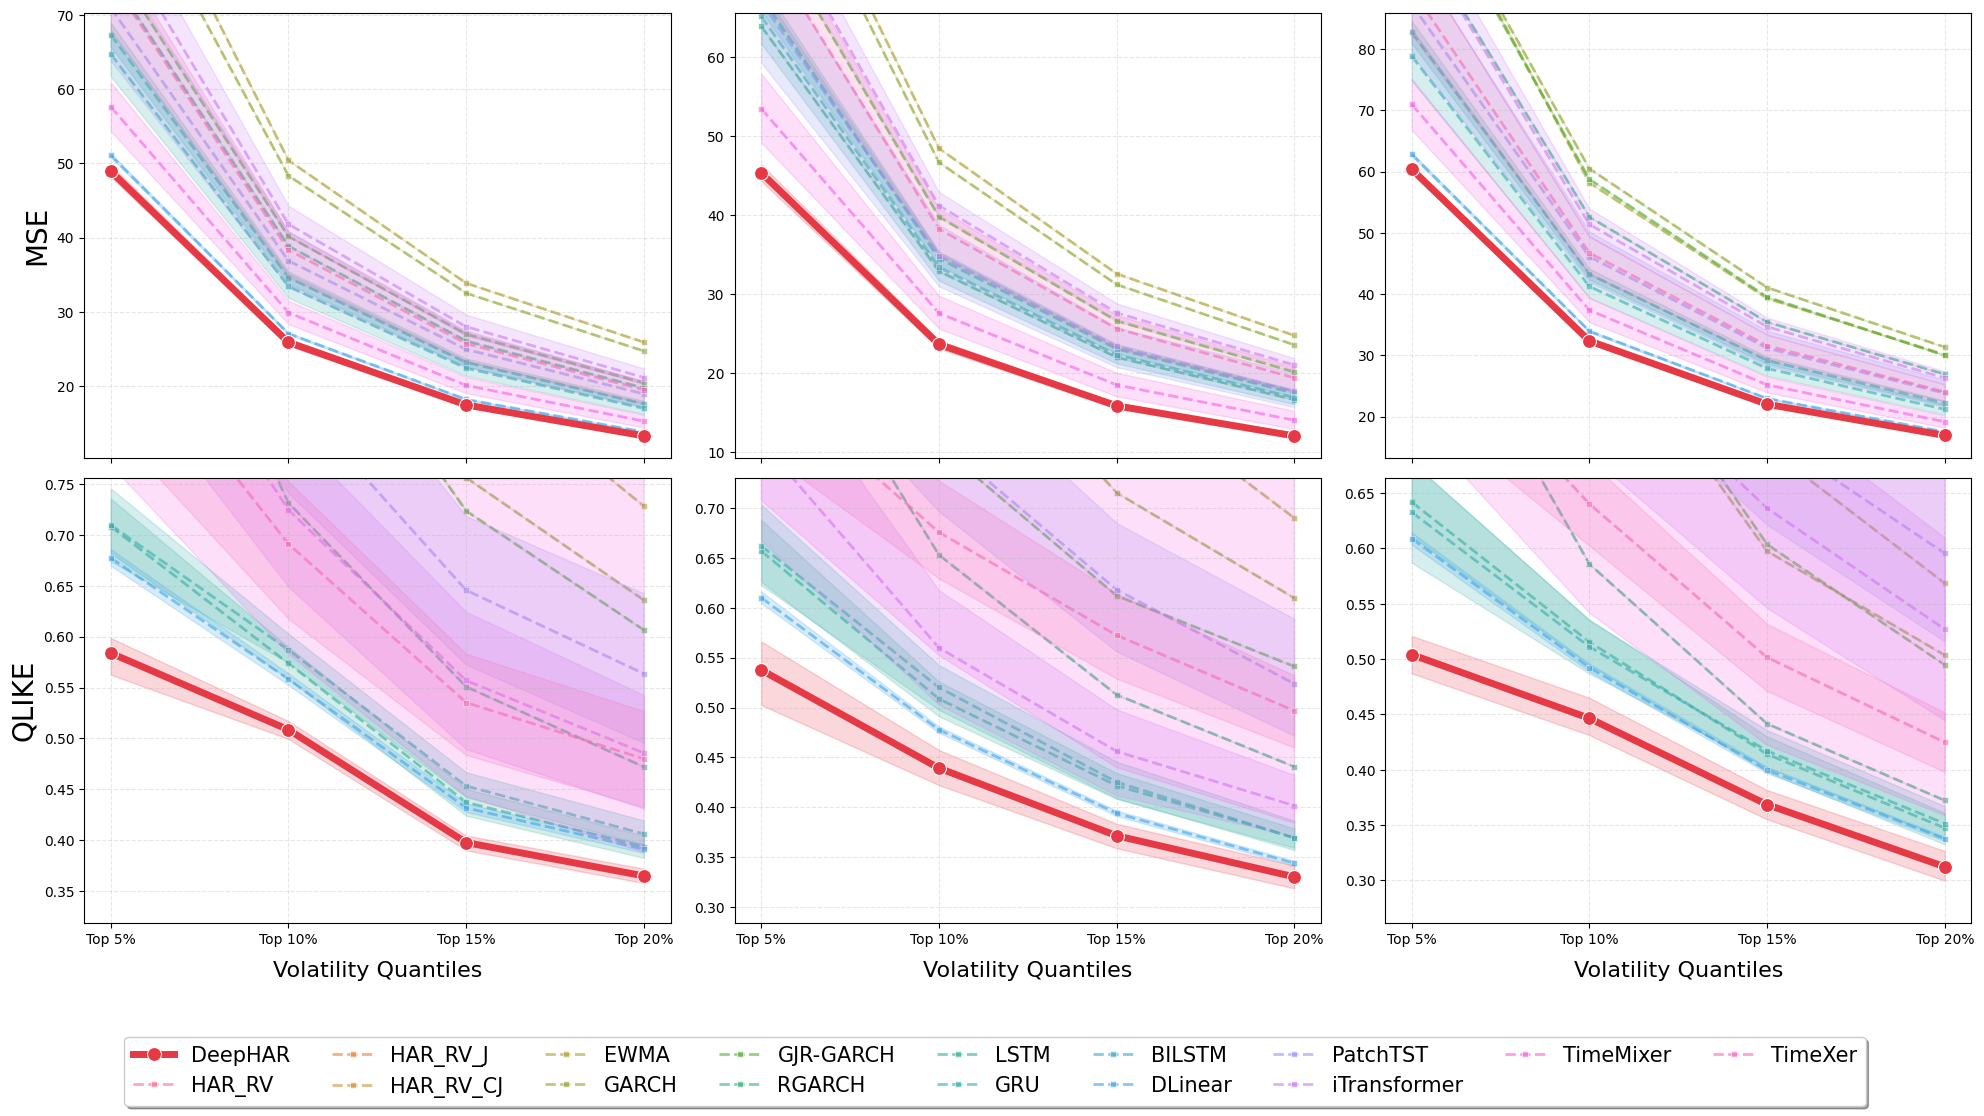

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. 누적 구간 설정 (Top 1% -> Top 5% -> Top 10% -> Top 20% 순으로 확장)
quantiles_to_plot = [0.95, 0.90, 0.85, 0.80]
labels = ['Top 5%', 'Top 10%', 'Top 15%', 'Top 20%']
regime_plot_list = []

# 2. 데이터 집계 루프
for seed, seed_df in results_plot.groupby('random_seed'):
    for symbol in ['SPY', 'DIA', 'QQQ']:
        target_df = seed_df.query('symbol == @symbol and model == "target"').set_index('date').sort_index()
        if target_df.empty: continue
        
        for model in model_order:
            pred_df = seed_df.query('symbol == @symbol and model == @model').set_index('date').sort_index()
            
            for i, q in enumerate(quantiles_to_plot):
                # [누적 로직] q 분위수보다 큰 모든 데이터를 포함 (예: Top 1%, Top 5% 누적...)
                threshold = target_df['pred'].quantile(q)
                target_regime = target_df[(target_df['pred'] >= threshold) ]
                regime_indices = target_regime.index
                
                matched_pred = pred_df.reindex(regime_indices).dropna(subset=['pred'])
                matched_target = target_regime.loc[matched_pred.index]
                
                if len(matched_target) > 0:
                    r_target = matched_target['pred'].values
                    r_pred = matched_pred['pred'].values
                    for loss_name, loss_fn in loss_metrics.items():
                        perf = loss_fn(r_pred, r_target)
                        regime_plot_list.append({
                            'Market': symbol, 'Metric': loss_name, 'Regime': labels[i],
                            'Model': model, 'Performance': perf
                        })

df_plot = pd.DataFrame(regime_plot_list)

# 3. 시각화 설정
fig, axes = plt.subplots(2, 3, figsize=(20, 11), sharex=True)
metrics = ['MSE', 'QLIKE']
symbols = ['SPY', 'DIA', 'QQQ']
target_model = 'DeepHAR'

# 모델별 컬러 (DeepHAR: Red, 나머지: Soft 유채색)
other_models = [m for m in model_order if m != target_model]
soft_palette = sns.color_palette("husl", n_colors=len(other_models)) 
model_colors = {model: soft_palette[i] for i, model in enumerate(other_models)}
model_colors[target_model] = '#E63946'

for m_idx, metric in enumerate(metrics):
    for s_idx, symbol in enumerate(symbols):
        ax = axes[m_idx, s_idx]
        subset = df_plot[(df_plot['Metric'] == metric) & (df_plot['Market'] == symbol)]
        
        for model in model_order:
            m_data = subset[subset['Model'] == model]
            is_target = (model == target_model)
            
            sns.lineplot(
                data=m_data, x='Regime', y='Performance',
                color=model_colors[model],
                linewidth=5 if is_target else 2.0,
                linestyle='-' if is_target else '--',
                marker='o' if is_target else 's',
                markersize=10 if is_target else 5,
                alpha=1.0 if is_target else 0.6,
                label=model, ax=ax, zorder=10 if is_target else 1
            )
        
        # --- [누적 그래프용 축 조절] ---
        # 누적 데이터이므로 구간이 넓어질수록(오른쪽으로 갈수록) 오차가 평균화되어 낮아지는 경향이 있음
        target_perf = subset[subset['Model'] == target_model]['Performance']
        if metric == 'MSE':
            # 제안 모델 최대값의 1.4배로 제한 (이탈 모델 강조)
            ax.set_ylim(target_perf.min() * 0.8, target_perf.max() * 1.4)
        else:
            # QLIKE: 더욱 타이트하게 비교
            ax.set_ylim(target_perf.min() * 0.9, target_perf.max() * 1.25)
        if m_idx == 1: # 아래쪽 서브플롯에만 x축 제목 표시
            ax.set_xlabel('Volatility Quantiles', fontsize=16,  labelpad=10)
        # if s_idx == 0:
        #     ax.set_ylabel(f'{metric}', fontsize=20)
        if s_idx == 0:
            ax.set_ylabel(f'{metric}', fontsize=20)
        else:
            ax.set_ylabel('')  # 나머지 열은 레이블 숨기기
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.get_legend().remove()

# 4. 통합 범례
handles, labels_legend = axes[0, 0].get_legend_handles_labels()
order = [labels_legend.index(target_model)] + [i for i, l in enumerate(labels_legend) if l != target_model]
fig.legend([handles[i] for i in order], [labels_legend[i] for i in order], 
           loc='lower center', ncol=len(model_order)//2 + 1, 
           fontsize=15, frameon=True, shadow=True, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.savefig("result/Figure7.png", dpi=300, bbox_inches='tight')
plt.show()

In [18]:
for model in  model_all:
   for symbol in symbols :
       q15 = np.quantile(seed_df.query('symbol == @symbol and model == "target"').pred, 0.8)
       model_i_results = np.zeros((5,2))
       for i, seed in enumerate(seed_list):
            seed_df = results.query('random_seed == @seed')
            target_vals = seed_df.query('symbol == @symbol and model == "target"').set_index('date').pred.values
            idx = target_vals>=q15
            model_vals = seed_df.query('symbol == @symbol and model == @model').set_index('date').pred.values
            target_vals = target_vals[idx]
            model_vals = model_vals[idx]
            model_i_results[i,0] = QLIKE(model_vals, target_vals)
            model_i_results[i,1] = MSE(model_vals, target_vals)
       print(symbol, model, np.mean(model_i_results, axis=0), np.std(model_i_results, axis=0))

SPY DeepHAR [ 0.36503435 13.26594111] [0.00793953 0.22718362]
DIA DeepHAR [ 0.33031095 12.05637075] [0.01314743 0.29549342]
QQQ DeepHAR [ 0.31225067 16.91325317] [0.01486404 0.17378781]
SPY HAR_RV [ 0.38180951 15.15190029] [0. 0.]
DIA HAR_RV [ 0.33048092 13.53049657] [0. 0.]
QQQ HAR_RV [ 0.35474351 19.29894652] [0. 0.]
SPY HAR_RV_J [ 0.44010376 14.94195732] [5.55111512e-17 0.00000000e+00]
DIA HAR_RV_J [ 0.33074466 13.20163613] [0. 0.]
QQQ HAR_RV_J [ 0.3597211  18.83664546] [0. 0.]
SPY HAR_RV_CJ [ 0.38725186 15.11980806] [0.00000000e+00 1.77635684e-15]
DIA HAR_RV_CJ [ 0.32921822 13.49266539] [0. 0.]
QQQ HAR_RV_CJ [ 0.36037342 19.238438  ] [0. 0.]
SPY EWMA [ 0.72824848 25.8994172 ] [0. 0.]
DIA EWMA [ 0.68999745 24.76514014] [0. 0.]
QQQ EWMA [ 0.56853247 30.10576707] [0. 0.]
SPY GARCH [ 0.63597393 24.71579785] [0. 0.]
DIA GARCH [ 0.60978262 23.58448204] [0. 0.]
QQQ GARCH [ 0.50353692 31.34137036] [0.00000000e+00 3.55271368e-15]
SPY GJR-GARCH [ 0.60659456 20.41531466] [0. 0.]
DIA GJR-GARCH

## Table 5 - Portfolio utility gains

In [19]:
def U(prediction_samples, labels, gamma=2):
    prediction_samples = prediction_samples.ravel()
    labels = labels.ravel()
    pred_safe = np.maximum(prediction_samples, 1e-8)
    term1 = 0.08 * (np.sqrt(labels) / np.sqrt(pred_safe))
    term2 = 0.04 * (labels / pred_safe)
    
    return np.mean(term1 - term2)

In [24]:
import pandas as pd
import numpy as np

# 1. 설정 및 수집 준비
symbols = ['SPY', 'DIA', 'QQQ']
all_utility_list = []

# 2. 루프 실행 (Seed -> Market -> Model)
for seed, seed_df in results.groupby('random_seed'):
    analysis_targets = symbols + ['ALL']
    
    for target_name in analysis_targets:
        # 데이터 필터링 (ALL인 경우 전체 합산)
        work_df = seed_df.copy() if target_name == 'ALL' else seed_df[seed_df['symbol'] == target_name]
        
        # 실제값(target)과 예측값(pred) 정렬 및 추출
        pivot = work_df.pivot_table(index=['date', 'symbol'], columns='model', values='pred')
        
        # 모델별 Utility 계산
        comparison_models = [m for m in model_order if m in pivot.columns and m != 'target']
        
        for model_name in comparison_models:
            # 유틸리티 함수 호출 및 % 변환 (100 곱하기)
            u_val = U(pivot[model_name].values, pivot['target'].values) * 100
            
            all_utility_list.append({
                'seed': seed,
                'Market': target_name,
                'Model': model_name,
                'Utility_PCT': u_val
            })

# 3. 데이터프레임 변환 및 통계 산출
df_u_all = pd.DataFrame(all_utility_list)
u_stats = df_u_all.groupby(['Market', 'Model'])['Utility_PCT'].agg(['mean', 'std']).reset_index()

# 4. "평균 ± 표준편차 (%)" 포맷팅 (소수점 3자리)
u_stats['display'] = u_stats.apply(lambda r: f"{r['mean']:.3f}%", axis=1)

# 5. Pivot 및 최종 정렬
u_pivot = u_stats.pivot(index='Model', columns='Market', values='display')

# 행 순서 (기존 model_order 기준)
existing_models = [m for m in model_order if m in u_pivot.index]
u_pivot = u_pivot.reindex(index=existing_models)

# 열 순서 (Market 순서)
u_pivot = u_pivot.reindex(columns=['SPY', 'DIA', 'QQQ', 'ALL'])

# 6. 저장 및 결과 확인
output_path = "result/Table5.csv"
u_pivot.to_csv(output_path, encoding="cp949")

print("--- Utility Score (%) Mean  ---")
print(u_pivot)

--- Utility Score (%) Mean  ---
Market           SPY     DIA     QQQ     ALL
Model                                       
HAR_RV        3.525%  3.624%  3.594%  3.581%
HAR_RV_J      3.486%  3.621%  3.589%  3.565%
HAR_RV_CJ     3.520%  3.627%  3.588%  3.578%
EWMA          3.237%  3.356%  3.383%  3.325%
GARCH         3.303%  3.401%  3.445%  3.383%
GJR-GARCH     3.325%  3.449%  3.457%  3.410%
RGARCH        3.411%  3.534%  3.519%  3.488%
LSTM          3.527%  3.619%  3.575%  3.574%
GRU           3.522%  3.623%  3.574%  3.573%
BILSTM        3.512%  3.615%  3.562%  3.563%
DLinear       3.518%  3.626%  3.578%  3.574%
PatchTST      3.437%  3.536%  3.421%  3.465%
iTransformer  3.464%  3.574%  3.457%  3.498%
TimeMixer     3.170%  3.150%  3.229%  3.183%
TimeXer       3.450%  3.511%  3.501%  3.487%
DeepHAR       3.544%  3.643%  3.592%  3.593%
